# Leaving out time points

***

Jan T. Schleicher, 2025

Here, we leave out individual time points from the data and perform exploratory trajectory inference on the other three time points. This allows us to judge better whether arbitrary trajectories are induced based on changes in cell locations.

To properly address this, we normalize and scale subsetted data again and recompute PCA, neighbors, velocities, and UMAP embeddings.

In [1]:
import os

import cy2path as c2p
import numpy as np
import scanpy as sc
import scvelo as scv
import torch
from matplotlib import pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

In [2]:
DATA_PATH = "../data/"
OUTPUT_PATH = "../output/omitting_timepoints/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

## Preprocessing

In [3]:
# Import preprocessed and raw AnnData objects
adata_raw = sc.read_h5ad(os.path.join(DATA_PATH, "tex_data_chronic.h5ad"))
display(adata_raw)
adata = sc.read_h5ad(os.path.join(DATA_PATH, "tex_data_chronic_annotated.h5ad"))
adata

AnnData object with n_obs × n_vars = 13763 × 27998
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [4]:
# Preprocess data subsets
adata_raw_sub = adata_raw[adata.obs_names, :]
adata_raw_sub.obs[["leiden", "annot"]] = adata.obs[["leiden", "annot"]].copy()
adata_raw_sub.var["mitochondrial"] = adata_raw_sub.var_names.str.startswith("mt-")
adata_raw_sub.var["ribosomal"] = adata_raw_sub.var_names.str.startswith(("Rps", "Rpl"))

adatas = {}
for tp in adata.obs.timepoint.cat.categories:
    adata_ = adata_raw_sub[adata_raw_sub.obs.timepoint != tp].copy()

    # QC filtering of genes; we use all cells that passed QC for the
    #   original, full data (subset to exclude one time point)
    scv.pp.filter_genes(adata_, min_shared_counts=20)

    # Cell cycle scoring
    cell_cycle_genes = [
        x.strip().capitalize()
        for x in open(os.path.join(DATA_PATH, "regev_lab_cell_cycle_genes.txt"))
    ]
    s_genes = cell_cycle_genes[:43]
    g2m_genes = cell_cycle_genes[43:]

    adata_copy = sc.pp.normalize_total(adata_, copy=True)
    sc.pp.log1p(adata_copy)
    sc.pp.scale(adata_copy)

    sc.tl.score_genes_cell_cycle(adata_copy, s_genes=s_genes, g2m_genes=g2m_genes)

    adata_.obs["phase"] = adata_copy.obs.phase
    adata_.obs["S_score"] = adata_copy.obs.S_score
    adata_.obs["G2M_score"] = adata_copy.obs.G2M_score
    adata_.obs["score_diff"] = adata_.obs.S_score - adata_.obs.G2M_score

    adata_.var["cell_cycle_genes"] = False
    adata_.var.loc[
        [gene for gene in cell_cycle_genes if gene in adata_.var_names],
        "cell_cycle_genes",
    ] = True

    # Normalize and select HVGs
    adata_.layers["counts"] = adata_.X.copy()
    scv.pp.filter_and_normalize(
        adata_,
        flavor="cell_ranger",
        log=True,
        n_top_genes=5000,
        subset_highly_variable=False,
    )

    # Remove mitochondrial and ribosomal genes
    keep_genes = np.intersect1d(
        adata_.var.index[~adata_.var.mitochondrial],
        adata_.var.index[~adata_.var.ribosomal],
    )
    adata_ = adata_[:, keep_genes]

    # Dimensionality reduction
    adata_.layers["log1p"] = adata_.X.copy()
    sc.pp.scale(adata_)
    adata_.layers["scaled"] = adata_.X.copy()
    sc.pp.regress_out(adata_, ["score_diff"])
    sc.pp.scale(adata_)

    sc.pp.pca(adata_, use_highly_variable=True)
    sc.pp.neighbors(adata_, use_rep="X_pca", n_neighbors=30, random_state=42)
    sc.tl.umap(adata_, random_state=42)

    adatas[tp] = adata_

Filtered out 21350 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 5000 highly variable genes.
Logarithmized X.


... storing 'phase' as categorical


Filtered out 21261 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 5000 highly variable genes.
Logarithmized X.


... storing 'phase' as categorical


Filtered out 21176 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 5000 highly variable genes.
Logarithmized X.


... storing 'phase' as categorical


Filtered out 20985 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 5000 highly variable genes.
Logarithmized X.


... storing 'phase' as categorical


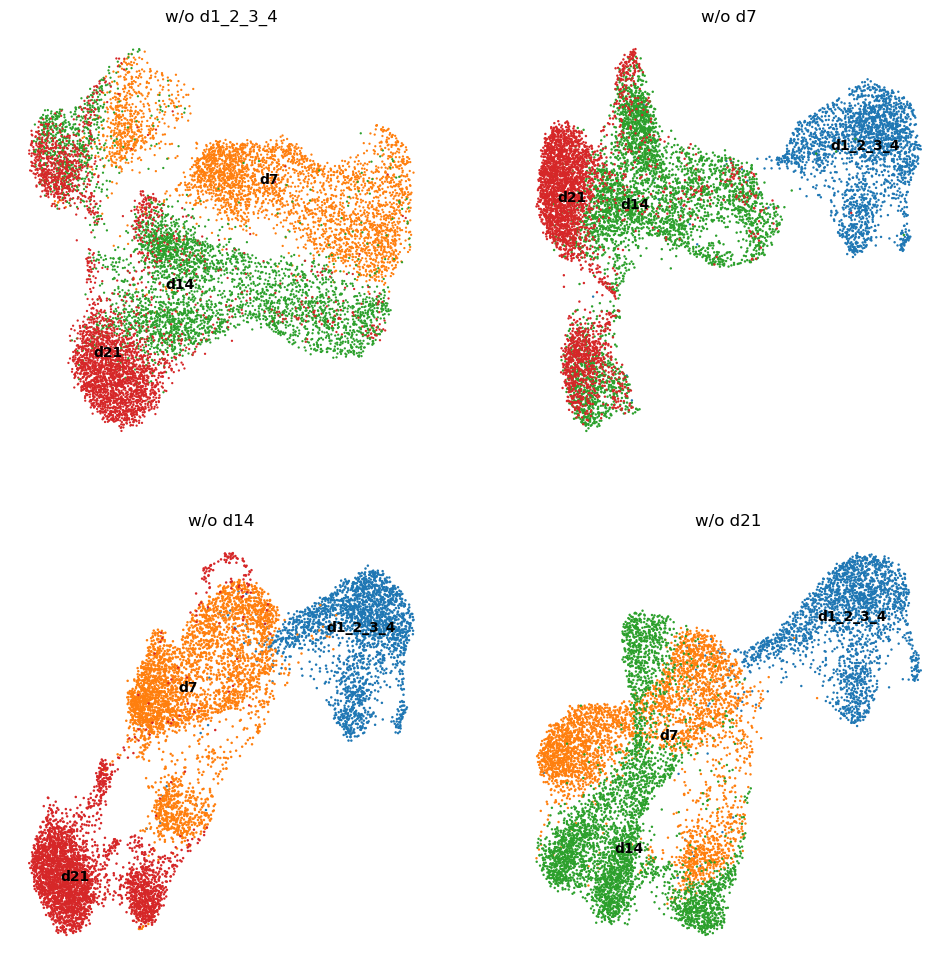

In [5]:
# Plot embeddings for each subset
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for i, (tp, adata_) in enumerate(adatas.items()):
    adata_.uns["timepoint_colors"] = np.asarray(
        adata.uns["sampleID_colors"][:i].tolist()
        + adata.uns["sampleID_colors"][i + 1 :].tolist()
    )
    sc.pl.umap(
        adata_,
        color="timepoint",
        show=False,
        ax=axs.flat[i],
        frameon=False,
        title=f"w/o {tp}",
        legend_loc="on data",
    )

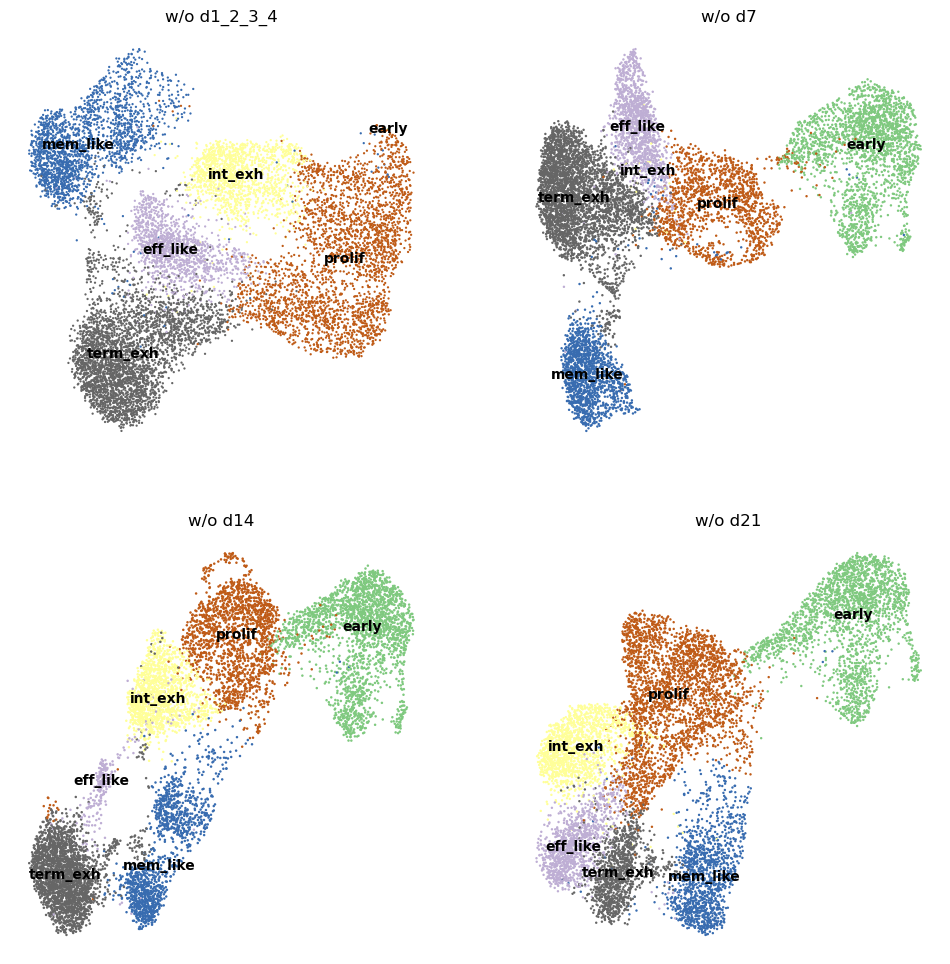

In [6]:
# Plot embeddings for each subset
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for i, (tp, adata_) in enumerate(adatas.items()):
    adata_.uns["annot_colors"] = adata.uns["annot_colors"]
    sc.pl.umap(
        adata_,
        color="annot",
        show=False,
        ax=axs.flat[i],
        frameon=False,
        title=f"w/o {tp}",
        legend_loc="on data",
    )

## RNA velocity analysis

In [7]:
# RNA velocity analysis
for adata_ in adatas.values():
    scv.pp.moments(adata_)
    scv.tl.velocity(adata_, mode="stochastic")
    scv.tl.velocity_graph(adata_, mode_neighbors="connectivities", n_jobs=-1)
    scv.tl.terminal_states(adata_)
    adata_.obsp["T_forward"] = scv.utils.get_transition_matrix(
        adata_, self_transitions=False
    )
    scv.tl.velocity_embedding(adata_)

computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 10/10 cores)


  0%|          | 0/11181 [00:00<?, ?cells/s]

    finished (0:00:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 10/10 cores)


  0%|          | 0/9814 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 10/10 cores)


  0%|          | 0/9321 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 10/10 cores)


  0%|          | 0/9914 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:869: MatplotlibDeprecationWarning: The draw_all function was deprecated in Matplotlib 3.6 and will be removed two minor releases later. Use fig.draw_without_rendering() instead.
  cb.draw_all()
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:869: MatplotlibDeprecationWarning: The draw_all function was deprecated in Matplotlib 3.6 and will be removed two minor releases later. Use fig.draw_without_rendering() instead.
  cb.draw_all()
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:869: MatplotlibDeprecationWarning: The draw_all function was deprecated in Matplotlib 3.6 and will be removed two minor releases later. Use fig.draw_without_rendering() instead.
  cb.draw_all()
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:869: MatplotlibDepreca

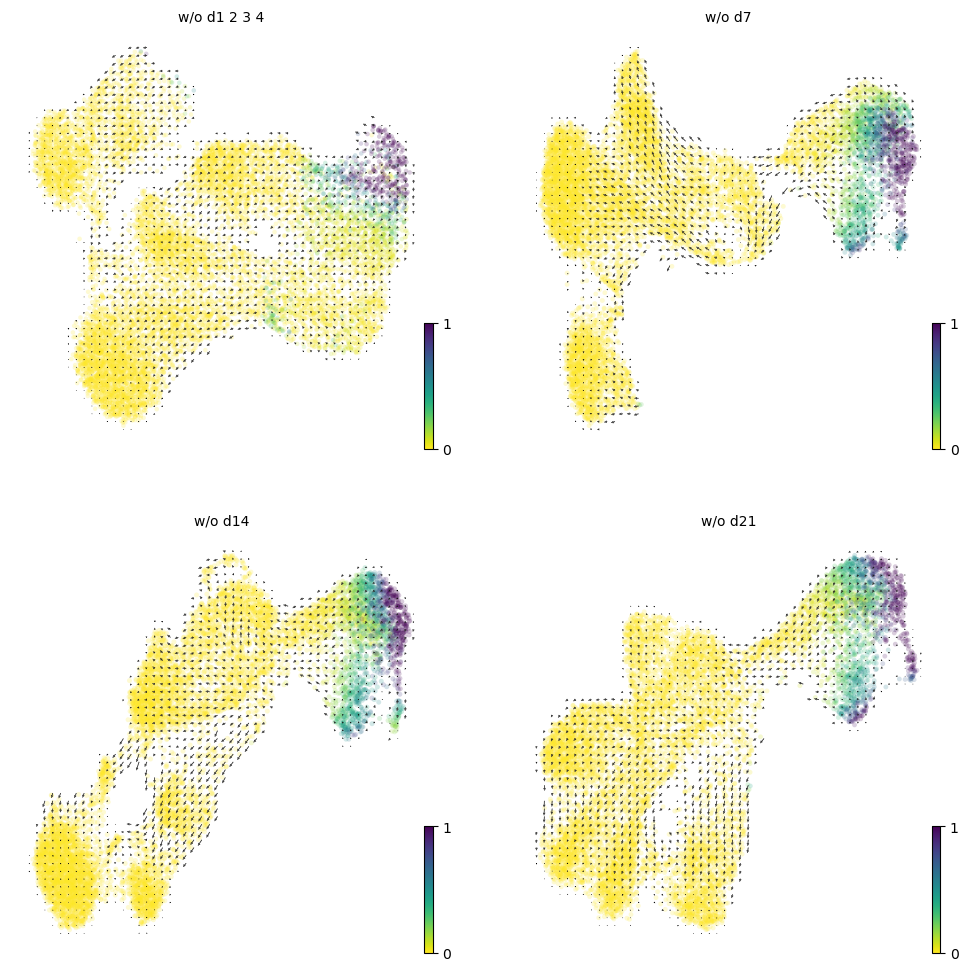

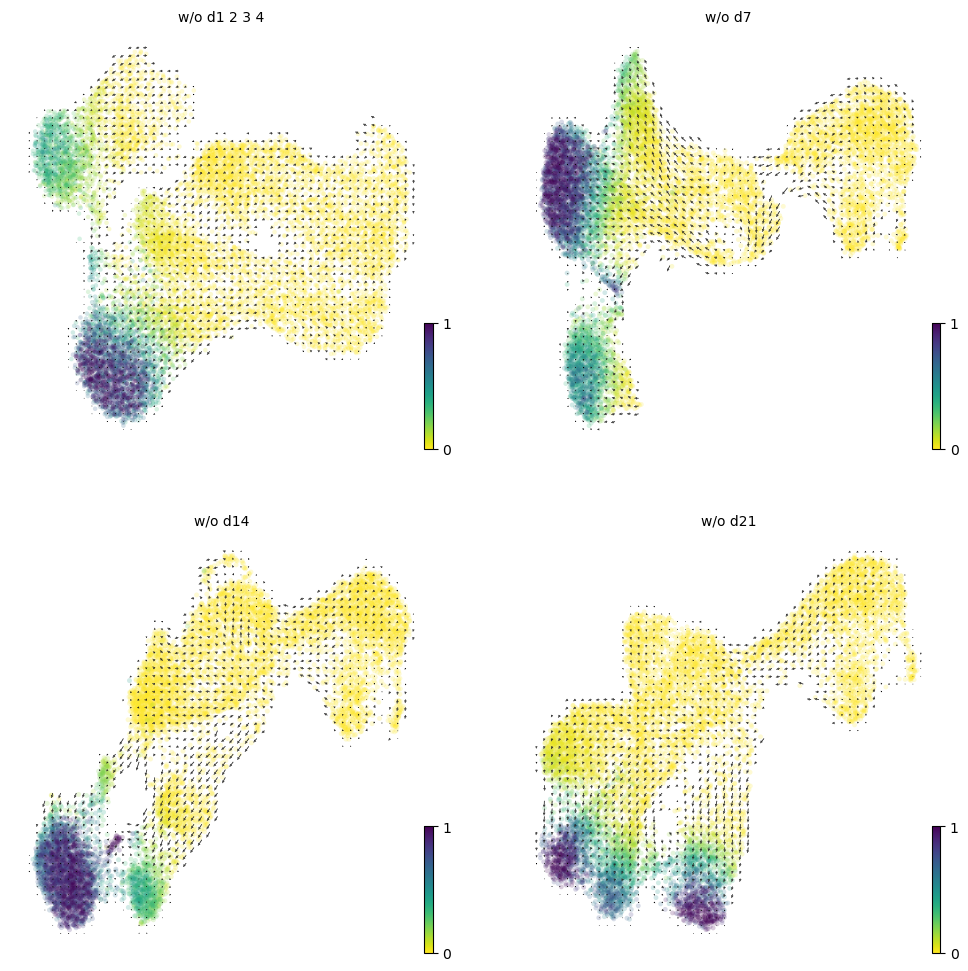

In [8]:
# Plot velocity embeddings for each subset
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for i, (tp, adata_) in enumerate(adatas.items()):
    scv.pl.velocity_embedding_grid(
        adata_,
        color="root_cells",
        show=False,
        ax=axs.flat[i],
        frameon=False,
        title=f"w/o {tp}",
    )

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for i, (tp, adata_) in enumerate(adatas.items()):
    scv.pl.velocity_embedding_grid(
        adata_,
        color="end_points",
        show=False,
        ax=axs.flat[i],
        frameon=False,
        title=f"w/o {tp}",
    )

## Perform exploratory trajectory inference

In [9]:
# Run Markov chain sampling
for adata_ in adatas.values():
    c2p.infer_cytopath_lineages(
        adata_,
        recalc_matrix=False,
        basis="pca",
        num_lineages=2,
        method="linkage",
        distance_func="dtw",
        differencing=False,
    )

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 130 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

...

INFO:root:Tolerance reached after 207 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

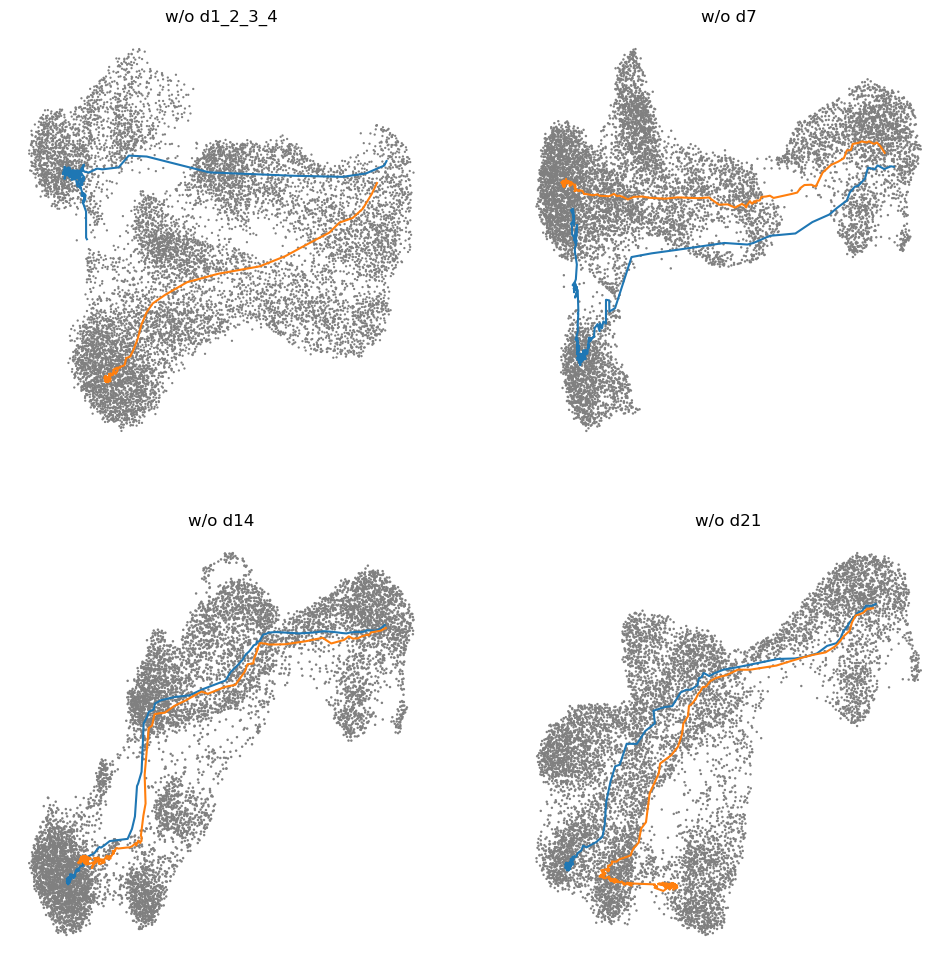

In [10]:
# Plot inferred lineages
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for i, (tp, adata_) in enumerate(adatas.items()):
    c2p.plot_cytopath_lineages(adata_, basis="umap", ax=axs.flat[i])
    axs.flat[i].set_title(f"w/o {tp}")

In [11]:
for tp, adata_ in adatas.items():
    adata_.write_h5ad(
        os.path.join(OUTPUT_PATH, f"tex_data_chronic_without_{tp}.h5ad"),
        compression="gzip",
    )